In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [2]:
np.random.seed(42)
num_samples = 500
years_of_experience = np.random.randint(2, 21, size=num_samples)
slope = (200000 - 60000) / 18
intercept = 60000
salaries = slope * years_of_experience + intercept + np.random.normal(0, 10000, size=num_samples)

data = {'Years_of_Experience': years_of_experience, 'Salary': salaries}
df = pd.DataFrame(data)

In [3]:
df.head()

,Years_of_Experience,Salary
0,8,115037.780010
1,16,182309.972927
2,12,156442.408989
3,9,144753.562169
4,8,130798.818454


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Years_of_Experience  500 non-null    int64  
 1   Salary               500 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 7.9 KB


In [5]:
df.describe()

,Years_of_Experience,Salary
count,500.000000,500.000000
mean,10.616000,142570.011096
std,5.662922,44935.263058
min,2.000000,54881.134555
25%,5.750000,104426.300731
50%,10.000000,139865.032545
75%,16.000000,182341.125962
max,20.000000,241879.376204


<Axes: xlabel='Years_of_Experience', ylabel='Salary'>

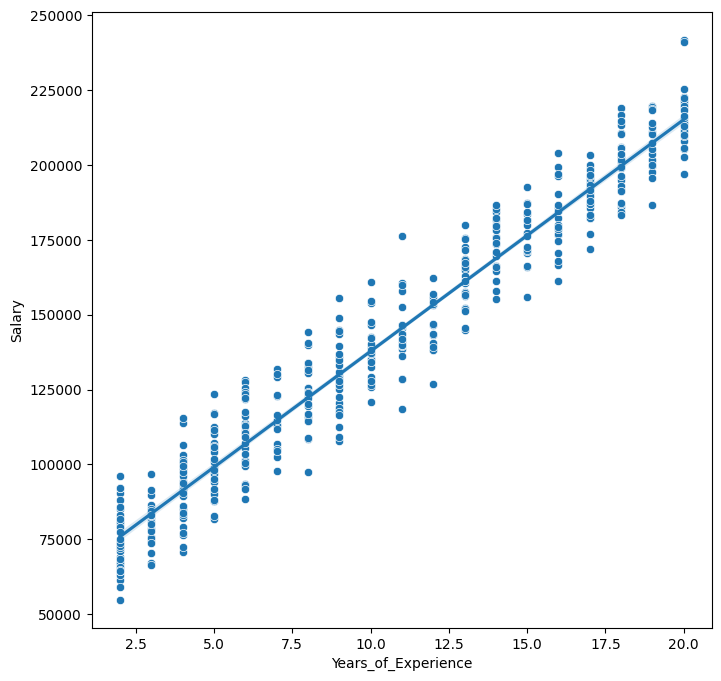

In [6]:
plt.figure(figsize=(8,8))
sns.scatterplot(x = 'Years_of_Experience', y='Salary', data=df)
sns.regplot(x = 'Years_of_Experience', y='Salary', data=df, scatter=False)

In [7]:
X = df[['Years_of_Experience']]
y = df[['Salary']]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
lr = LinearRegression()

In [10]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
y_pred = lr.predict(X_test)

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [13]:
mean_absolute_error(y_test, y_pred)

7905.114728709235

In [14]:
mean_squared_error(y_test, y_pred)

93933277.37947097

In [15]:
r2_score(y_test, y_pred)

0.9573704756930143

In [18]:
lr.coef_

array([[7696.61292305]])

In [19]:
lr.intercept_

array([60961.34088028])

In [20]:
coefficient = lr.coef_
intercept = lr.intercept_

x = np.linspace(0,20,100)
y = coefficient*x+intercept

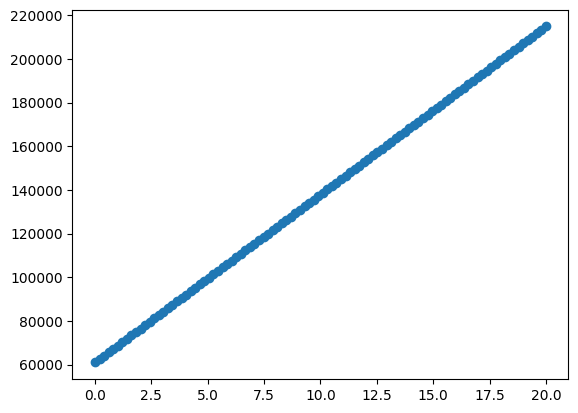

In [21]:
plt.scatter(x, y)